In [ ]:
import importlib
import logging
import os
import sys
from pathlib import Path

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import utils

    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia


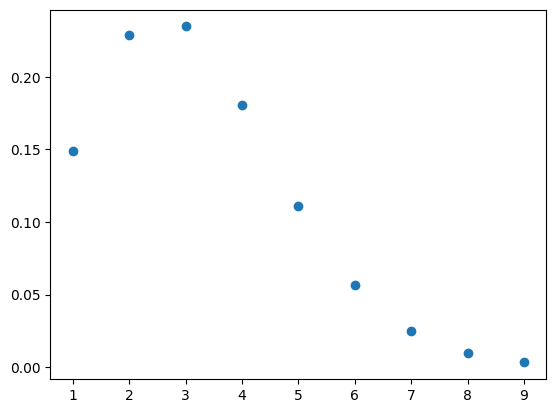

In [ ]:
abr = 160
weeks_of_years = 52
frequency_given_interval = abr / weeks_of_years
values = {}
for i in range(10):
    if i == 0:
        continue
    values[i] = utils.zero_truncated_mass_function(lam=frequency_given_interval, k=i)

import matplotlib.pyplot as plt

plt.scatter(values.keys(), values.values())  # type: ignore

In [27]:
import numpy as np
from sklearn.preprocessing import normalize

array = np.array([0.25, 0.10, 0.65, 0.18, 0.9])
print(len(array.shape))
norm = normalize(array.reshape(-1, 1), "l1", axis=0)
print(array)
print(norm.ravel())
print(norm.sum())

1
[0.25 0.1  0.65 0.18 0.9 ]
[0.12019231 0.04807692 0.3125     0.08653846 0.43269231]
1.0


In [42]:
import math
from time import time

import numpy as np
from numba import jit


def zero_truncated_mass_function(
    lam: int | float | np.number | np.int64, k: int | float | np.number
) -> float:
    """
    Zero-Truncated Poisson PMF: (λ**k) / ((e**λ) -1) * k!
    Args:
        k: value(s) to evaluate the PMF at (must be integer >= 1).
        lam: rate parameter of the underlying poisson distribution.
    """
    # The classic ZTP formula
    if not isinstance(k, int | float | np.number):
        raise TypeError(f"Invalid input, expected number value, got {type(k)}")
    if k == 0:
        raise ValueError("zero is truncated")
    numerator = np.power(lam, k)
    denominator = (math.exp(lam) - 1) * math.factorial(int(k))
    res = numerator / denominator
    return res


@jit(nopython=True)
def factorial_numba(n: int):
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


@jit(nopython=True, cache=True)
def fast_truncated_mass_function(lam: float, k: int):
    if k == 0:
        raise ValueError("Zero is truncated")
    return np.power(lam, k) / ((np.exp(lam) - 1) * factorial_numba(k))


def bench(func, **kwargs):
    start = time()
    for i in range(1_000_000):
        func(**kwargs)
    exc_time = time() - start
    print(f"1_000_000 executions took {exc_time} seconds")


bench(fast_truncated_mass_function, lam=0.5, k=2)
bench(zero_truncated_mass_function, lam=0.5, k=2)

1_000_000 executions took 0.43927526473999023 seconds
1_000_000 executions took 3.164548635482788 seconds
